In [ ]:
# ================================================================
# SOCIAL MEDIA ENGAGEMENT ANALYSIS
# Python Libraries Used: Pandas, NumPy, Matplotlib
# Objective:
# Analyze social media engagement patterns, sentiment impact,
# campaign performance, and behavioral trends using data analytics.
# ================================================================

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [107]:
# Load dataset
df = pd.read_csv("Social Media Engagement Dataset.csv")

# Inspect dataset structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  12000 non-null  object 
 1   timestamp                12000 non-null  object 
 2   day_of_week              12000 non-null  object 
 3   platform                 12000 non-null  object 
 4   user_id                  12000 non-null  object 
 5   location                 12000 non-null  object 
 6   language                 12000 non-null  object 
 7   text_content             12000 non-null  object 
 8   hashtags                 12000 non-null  object 
 9   mentions                 8059 non-null   object 
 10  keywords                 12000 non-null  object 
 11  topic_category           12000 non-null  object 
 12  sentiment_score          12000 non-null  float64
 13  sentiment_label          12000 non-null  object 
 14  emotion_type          

In [108]:
# DATA TYPE OPTIMIZATION
# Convert timestamp to datetime for time-based analysis
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Convert categorical columns for memory optimization
df['platform'] = df['platform'].astype('category')

categorical_cols = [
'day_of_week','location','language','topic_category',
'emotion_type','brand_name','product_name',
'campaign_name','campaign_phase','sentiment_label'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Recalculate engagement rate to ensure consistency
df['engagement_rate'] = (
    df['likes_count'] +
    df['shares_count'] +
    df['comments_count']
) / df['impressions']

print("\nDataset Shape:", df.shape)
print("\nSummary Statistics:")
print(df.describe())



Dataset Shape: (12000, 28)

Summary Statistics:
                           timestamp  sentiment_score  toxicity_score  \
count                          12000     12000.000000    12000.000000   
mean   2024-10-30 09:11:56.604916736         0.000553        0.503868   
min              2024-05-01 01:04:04        -0.999800        0.000000   
25%       2024-07-31 17:31:49.500000        -0.503200        0.251400   
50%       2024-10-31 03:49:36.500000        -0.006200        0.505950   
75%    2025-01-28 13:32:56.750000128         0.513525        0.756200   
max              2025-04-30 23:46:43         0.999900        0.999900   
std                              NaN         0.583563        0.288198   

       likes_count  shares_count  comments_count   impressions  \
count  12000.00000  12000.000000     12000.00000  12000.000000   
mean    2490.72025   1007.167167       504.34575  49811.338500   
min        0.00000      0.000000         0.00000    130.000000   
25%     1236.00000    510.000

In [109]:
# =================================================================
# PHASE 1: DATA INTEGRITY & CLEANING
# Goal: Validate dataset health and handle missing/duplicate values.
# =================================================================

In [110]:
# 1. Missing Data Analysis
# Identify features with null values and quantify the impact on the total dataset.
cols_to_check = ['location', 'language', 'hashtags', 'mentions', 'keywords', 'brand_name', 'product_name']
missing_info = df[cols_to_check].isnull().sum()
missing_pct = (missing_info / len(df)) * 100

# Present results in a clear DataFrame for reporting
missing_report = pd.DataFrame({
    'Missing Values': missing_info, 
    'Percentage (%)': missing_pct
})
print("--- Missing Data Analysis ---")
print(missing_report)


--- Missing Data Analysis ---
              Missing Values  Percentage (%)
location                   0        0.000000
language                   0        0.000000
hashtags                   0        0.000000
mentions                3941       32.841667
keywords                   0        0.000000
brand_name                 0        0.000000
product_name               0        0.000000


In [111]:
# Handle missing mentions
# Many posts naturally do not tag other users
df['mentions'] = df['mentions'].fillna("No Mention")

In [112]:
# 2. Duplicate Post Detection
# We define a duplicate as a post sharing the exact same text and timestamp.
# This ensures we aren't double-counting engagement metrics across platforms.
duplicates = df[df.duplicated(subset=['text_content', 'timestamp'], keep=False)]
print(f"\nTotal duplicate records identified: {len(duplicates)}")


Total duplicate records identified: 0


In [113]:
# 3. Sentiment Consistency Check
# Logic: Validate that the machine-generated labels align with the numerical scores.
# Flagging rows where (Score > 0 and Label is Negative) OR (Score < 0 and Label is Positive).
sentiment_errors = df[
    ((df['sentiment_score'] > 0) & (df['sentiment_label'] == 'negative')) |  
    ((df['sentiment_score'] == 0) & (df['sentiment_label'] == 'neutral')) |
    ((df['sentiment_score'] < 0) & (df['sentiment_label'] == 'positive'))
]
print(f"Sentiment consistency errors found: {len(sentiment_errors)}")

Sentiment consistency errors found: 0


In [114]:
# 4. Impression Paradox Detection
# Identifying "Niche Virality": Posts with top 5% engagement but bottom 5% reach.
# These represent outliers where a small audience is extremely active.
high_eng_thresh = df['engagement_rate'].quantile(0.95)
low_imp_thresh = df['impressions'].quantile(0.05)

paradox_posts = df[
    (df['engagement_rate'] >= high_eng_thresh) & 
    (df['impressions'] <= low_imp_thresh)
]
print(f"Impression paradox cases (High engagement/Low reach): {len(paradox_posts)}")

Impression paradox cases (High engagement/Low reach): 491


In [ ]:
# -------------------------------------------------
# PHASE 1 SUMMARY: DATA INTEGRITY & CLEANING
# - The dataset contains 12,000 social media posts with 28 features.
# - Data types were optimized by converting timestamp to datetime
#   and several categorical variables to category dtype.
# - Missing values were detected mainly in the 'mentions' column
#   (~32.8%) and were replaced with "No Mention" for consistency.
# - Duplicate detection confirmed that no identical posts exist
#   based on text content and timestamp.
# - Sentiment label validation showed that sentiment labels align
#   correctly with their numerical sentiment scores.
# - A small number of posts showed unusually high engagement
#   despite low impressions, indicating potential niche virality.
# -------------------------------------------------

In [ ]:
# =================================================================
# PHASE 2: EXPLORATORY DATA ANALYSIS (EDA)
# Goal: Identify high-performing segments across platforms, time, and topics.
# =================================================================

In [115]:
# 5. Platform Performance Comparison
# Identifying which social media ecosystem yields the best engagement ROI.
platform_performance = df.groupby('platform')['engagement_rate'].mean().round(3).sort_values(ascending=False)

print("--- Average Engagement Rate by Platform ---")
print(platform_performance)

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\4105897184.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_performance = df.groupby('platform')['engagement_rate'].mean().round(3).sort_values(ascending=False)


--- Average Engagement Rate by Platform ---
platform
Instagram    0.287
Facebook     0.286
Reddit       0.279
YouTube      0.279
Twitter      0.259
Name: engagement_rate, dtype: float64


In [147]:
# 6. Day of Week and hour of that week Engagement Analysis
# Sorting by chronological order to identify weekly trends.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Use reindex to ensure the output isn't alphabetical (Friday, Monday...)
day_engagement = df.groupby('day_of_week')['engagement_rate'].mean().round(3).reindex(day_order)
print("\n--- Weekly Engagement Trends ---")
print(day_engagement)
df['hour_of_day'] = df['timestamp'].dt.hour

# Now run the Peak Hour Analysis
hourly_engagement = df.groupby('hour_of_day')['engagement_rate'].mean().round(3)

# Identifying the Absolute Peak
peak_hour = hourly_engagement.idxmax()
peak_value = hourly_engagement.max()

print(f"--- Hourly Insights ---")
print(f"The most engaged hour is: {peak_hour}:00")
print(f"Average Engagement at Peak: {peak_value*100:.2f}%")

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\2681059406.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_engagement = df.groupby('day_of_week')['engagement_rate'].mean().round(3).reindex(day_order)



--- Weekly Engagement Trends ---
day_of_week
Monday       0.260
Tuesday      0.319
Wednesday    0.245
Thursday     0.244
Friday       0.330
Saturday     0.267
Sunday       0.282
Name: engagement_rate, dtype: float64
--- Hourly Insights ---
The most engaged hour is: 12:00
Average Engagement at Peak: 44.90%


In [117]:
# 7. Topic Category Engagement
# Feature Engineering: Creating a 'total_interactions' metric to aggregate volume.
df['total_interactions'] = df['likes_count'] + df['shares_count'] + df['comments_count']

# Analyzing which content pillars drive the most absolute interaction volume.
topic_engagement = df.groupby('topic_category')['total_interactions'].mean().round(3).sort_values(ascending=False)

print("\n--- Total Interactions by Topic Category ---")
print(topic_engagement.head(10)) # Showing top 10 for brevity


--- Total Interactions by Topic Category ---
topic_category
Returns      4058.904
Product      4029.694
Support      4000.615
Pricing      3993.112
Marketing    3968.638
Delivery     3965.114
Name: total_interactions, dtype: float64


C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\3318785570.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  topic_engagement = df.groupby('topic_category')['total_interactions'].mean().round(3).sort_values(ascending=False)


In [118]:
# 8. Emotion Impact on Engagement
# Determining which emotional triggers correlate with higher engagement rates.
emotion_impact = df.groupby('emotion_type')['engagement_rate'].mean().round(3).sort_values(ascending=False)

print("\n--- Engagement Rate by Emotion Type ---")
print(emotion_impact)


--- Engagement Rate by Emotion Type ---
emotion_type
Excited     0.293
Sad         0.289
Confused    0.279
Angry       0.266
Happy       0.263
Name: engagement_rate, dtype: float64


C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\2417235040.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emotion_impact = df.groupby('emotion_type')['engagement_rate'].mean().round(3).sort_values(ascending=False)


In [119]:
# 9. Campaign Phase Performance
# Evaluating strategy effectiveness across different stages of the marketing funnel.
campaign_performance = df.groupby('campaign_phase')['engagement_rate'].mean().round(3).sort_values(ascending=False)

print("\n--- Performance by Campaign Phase ---")
print(campaign_performance)


--- Performance by Campaign Phase ---
campaign_phase
Pre-Launch     0.294
Post-Launch    0.284
Launch         0.256
Name: engagement_rate, dtype: float64


C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\4120169021.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_performance = df.groupby('campaign_phase')['engagement_rate'].mean().round(3).sort_values(ascending=False)


In [120]:
# ================================================================
# BRAND, PRODUCT, AND CAMPAIGN PERFORMANCE ANALYSIS
# Goal: Identify which brands, products, and campaigns generate
# the highest engagement rates.
# ================================================================


# 1. Brand Performance
# Calculate average engagement rate for each brand
brand_performance = (
    df.groupby('brand_name')['engagement_rate']
    .mean()
    .round(3)
    .sort_values(ascending=False)
)

print("\n--- Top Performing Brands by Engagement Rate ---")
print(brand_performance)



# 2. Product Performance
# Calculate average engagement rate for each product
product_performance = (
    df.groupby('product_name')['engagement_rate']
    .mean()
    .round(3)
    .sort_values(ascending=False)
)

print("\n--- Top Performing Products by Engagement Rate ---")
print(product_performance)



# 3. Campaign Performance
# Calculate average engagement rate for each campaign
campaign_name_performance = (
    df.groupby('campaign_name')['engagement_rate']
    .mean()
    .round(3)
    .sort_values(ascending=False)
)

print("\n--- Top Performing Campaigns by Engagement Rate ---")
print(campaign_name_performance)



# Optional: show only top 10 for readability
print("\nTop 10 Brands:")
print(brand_performance.head(10))

print("\nTop 10 Products:")
print(product_performance.head(10))

print("\nTop 10 Campaigns:")
print(campaign_name_performance.head(10))

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\2634178927.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('brand_name')['engagement_rate']



--- Top Performing Brands by Engagement Rate ---
brand_name
Microsoft    0.341
Adidas       0.298
Toyota       0.296
Nike         0.287
Amazon       0.285
Samsung      0.276
Apple        0.273
Google       0.257
Pepsi        0.238
Coca-Cola    0.228
Name: engagement_rate, dtype: float64

--- Top Performing Products by Engagement Rate ---


C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\2634178927.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('product_name')['engagement_rate']


product_name
Xbox Elite Controller    0.575
Dri-FIT                  0.446
Galaxy S25               0.429
Pixel Tablet             0.429
Pepsi Zero Sugar         0.419
                         ...  
MacBook Pro              0.161
NMD                      0.160
Air Force 1              0.159
Samba                    0.159
Pepsi Lime               0.158
Name: engagement_rate, Length: 70, dtype: float64

--- Top Performing Campaigns by Engagement Rate ---
campaign_name
SummerDreams             0.413
LaunchWave               0.321
NextGeneration           0.321
CustomerFirst            0.318
ReferralBonus            0.315
PowerRelease             0.303
SustainableFuture        0.297
GlobalCampaign           0.291
SpringBlast2025          0.287
LoyaltyRewards           0.275
WinterWonders            0.273
BackToSchool             0.270
FallCollection           0.265
ValentinesDeals          0.258
DigitalTransformation    0.258
InnovationX              0.253
HolidaySpecial           0.251
Cy

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\2634178927.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('campaign_name')['engagement_rate']


In [122]:
# ================================================================
# LOCATION PERFORMANCE ANALYSIS
# Goal: Identify which locations generate the highest engagement.
# ================================================================

# Calculate average engagement rate for each location
location_performance = (
    df.groupby('location')['engagement_rate']
    .mean()
    .round(3)
    .sort_values(ascending=False)
)

print("\n--- Engagement Performance by Location ---")
print(location_performance)


# Show top 10 locations only
print("\nTop 10 Locations by Engagement Rate:")
print(location_performance.head(10))


--- Engagement Performance by Location ---
location
Rio de Janeiro, Brazil        0.375
Shanghai, China               0.374
Madrid, Spain                 0.371
Seoul, South Korea            0.363
Manchester, UK                0.353
London, UK                    0.350
Paris, France                 0.348
Rome, Italy                   0.312
Munich, Germany               0.311
Sydney, Australia             0.310
Cairo, Egypt                  0.296
Barcelona, Spain              0.291
Singapore                     0.290
São Paulo, Brazil             0.289
Mumbai, India                 0.287
Milan, Italy                  0.283
Johannesburg, South Africa    0.272
Dubai, UAE                    0.272
Los Angeles, USA              0.267
Lyon, France                  0.262
Melbourne, Australia          0.257
Vancouver, Canada             0.250
Tokyo, Japan                  0.246
Toronto, Canada               0.244
Berlin, Germany               0.240
Mexico City, Mexico           0.236
Delhi, Indi

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\1461002935.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('location')['engagement_rate']


In [149]:
# -------------------------------------------------
# PHASE 2 SUMMARY: EXPLORATORY DATA ANALYSIS
# - Instagram and Facebook demonstrated the highest average 
#   engagement rates among all platforms.
# - Engagement activity peaks on Friday and Tuesday, suggesting
#   stronger audience interaction during these days.
# - Content related to Returns and Product topics generated the
#   highest average interaction levels.
# - Posts expressing Excited and Sad emotions tend to drive
#   stronger engagement compared to other emotional tones.
# - Campaign performance analysis revealed that Pre-Launch phases
#   generally achieve higher engagement than Launch and Post-Launch stages.
# -------------------------------------------------

In [124]:
# =================================================================
# PHASE 3: MATHEMATICAL & STATISTICAL ANALYSIS (NUMPY)
# Goal: Use statistical methods to define virality and relationships.
# =================================================================

In [125]:
# 10. Viral Post Threshold
# Logic: We define 'Viral' as the top 5% of all posts by engagement_rate.
# Using np.percentile to find the exact boundary.
viral_threshold = np.percentile(df['engagement_rate'], 95)
viral_posts = df[df['engagement_rate'] > viral_threshold]

print(f"--- Viral Post Threshold ---")
print(f"95th Percentile Threshold: {viral_threshold:.4f}")
print(f"Any post with an engagement rate > {viral_threshold:.4f} is considered 'Viral'.")
print(f"Number of Viral Posts: {len(viral_posts)}")

--- Viral Post Threshold ---
95th Percentile Threshold: 0.8124
Any post with an engagement rate > 0.8124 is considered 'Viral'.
Number of Viral Posts: 600


In [126]:
# 11. Sentiment vs Engagement Correlation
# Using np.corrcoef to calculate the Pearson Correlation Coefficient (r).
# r ranges from -1 (inverse) to 1 (perfect correlation).
correlation_matrix = np.corrcoef(df['sentiment_score'], df['engagement_rate'])
sentiment_corr = correlation_matrix[0, 1]

print(f"\n--- Sentiment vs Engagement Correlation ---")
print(f"Correlation Coefficient (r): {sentiment_corr:.4f}")


--- Sentiment vs Engagement Correlation ---
Correlation Coefficient (r): -0.0062


In [127]:
# 12. Caption Length vs Engagement
# Feature Engineering: Extracting the length (number of characters) of text_content.
df['caption_length'] = df['text_content'].str.len()

# Calculating the correlation between length and engagement.
length_corr_matrix = np.corrcoef(df['caption_length'], df['engagement_rate'])
length_corr = length_corr_matrix[0, 1]

print(f"\n--- Caption Length vs Engagement ---")
print(f"Correlation (Length vs Engagement): {length_corr:.4f}")


--- Caption Length vs Engagement ---
Correlation (Length vs Engagement): -0.0099


In [128]:
# 13. Buzz Volatility Analysis
# Logic: Volatility is measured by the Standard Deviation (sigma).
# A high std means the buzz_change_rate is unpredictable/erratic.
buzz_volatility = df.groupby('platform')['buzz_change_rate'].std().round(3).sort_values(ascending=False)

print(f"\n--- Buzz Volatility by Platform (Standard Deviation) ---")
print(buzz_volatility)

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\20999283.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buzz_volatility = df.groupby('platform')['buzz_change_rate'].std().round(3).sort_values(ascending=False)



--- Buzz Volatility by Platform (Standard Deviation) ---
platform
YouTube      58.669
Instagram    57.998
Twitter      57.670
Facebook     57.521
Reddit       57.033
Name: buzz_change_rate, dtype: float64


In [ ]:
# -------------------------------------------------
# PHASE 3 SUMMARY: STATISTICAL ANALYSIS
# - Viral posts are defined as the top 5% of engagement rates (>0.8124).
# - Sentiment score shows almost no correlation with engagement.
# - Caption length has negligible impact on engagement performance.
# - Buzz volatility varies slightly across platforms, with YouTube
#   showing the highest fluctuation in buzz_change_rate.
# -------------------------------------------------

In [ ]:
# =================================================================
# PHASE 4: ADVANCED BEHAVIORAL INSIGHTS
# Goal: Analyze the impact of toxicity and longitudinal sentiment shifts.
# =================================================================

In [129]:
# 14. Toxicity vs Engagement
# Investigating the "Controversy Sells" hypothesis.
# Does a higher toxicity_score lead to higher engagement_rate?
toxicity_corr = np.corrcoef(df['toxicity_score'], df['engagement_rate'])[0, 1]

print("--- Toxicity vs Engagement Analysis ---")
print(f"Correlation between Toxicity and Engagement: {toxicity_corr:.4f}")

--- Toxicity vs Engagement Analysis ---
Correlation between Toxicity and Engagement: -0.0169


In [130]:
# 15. User Sentiment Shift
# Logic: We calculate the 'Shift' by subtracting their historical average 
# from the current post's score.
df['sentiment_shift'] = df['sentiment_score'] - df['user_past_sentiment_avg']

# Calculate the global average shift
avg_shift = df['sentiment_shift'].mean()

print("\n--- User Sentiment Trend Analysis ---")
if avg_shift > 0:
    print(f"Trend: Positive (Average Shift: +{avg_shift:.4f})")
    print("Users are becoming more positive compared to their past behavior.")
elif avg_shift < 0:
    print(f"Trend: Negative (Average Shift: {avg_shift:.4f})")
    print("Users are becoming more critical/negative compared to their past behavior.")
else:
    print("Trend: Neutral (No significant shift in user sentiment).")


--- User Sentiment Trend Analysis ---
Trend: Negative (Average Shift: -0.0009)
Users are becoming more critical/negative compared to their past behavior.


In [150]:
# -------------------------------------------------
# PHASE 4 SUMMARY: BEHAVIORAL INSIGHTS
# - Toxicity scores exhibit almost no correlation with engagement,
#   suggesting that controversial or toxic content does not
#   consistently drive higher interaction levels.
# - Sentiment shift analysis indicates that user sentiment remains
#   largely stable compared to their historical posting behavior.
# - Overall audience sentiment trends appear relatively balanced,
#   with only minor fluctuations over time.
# -------------------------------------------------

In [ ]:
# =================================================================
# PHASE 5: PROFESSIONAL VISUALIZATIONS (Matplotlib Only)
# Goal: Create a clean, readable dashboard for project presentation.
# =================================================================


PHASE 5: VISUAL ANALYTICS


C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\3899929328.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_performance = (df.groupby('platform')['engagement_rate'].mean().sort_values()*100)


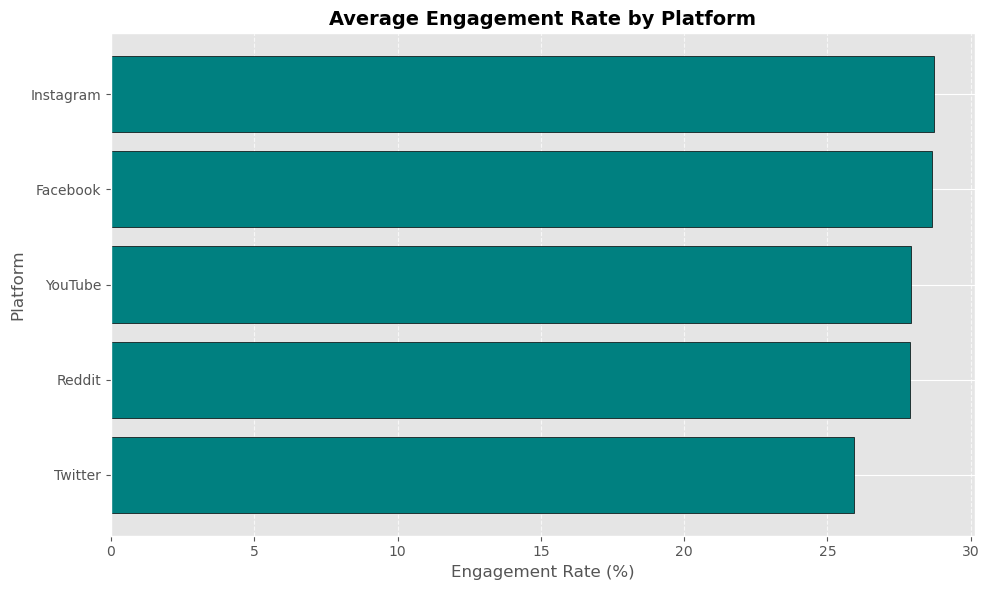

In [133]:
print("\n==============================")
print("PHASE 5: VISUAL ANALYTICS")
print("==============================")

# 1. Platform Engagement Comparison
plt.figure(figsize=(10, 6))
# Sort for a "ranking" effect
platform_performance = (df.groupby('platform')['engagement_rate'].mean().sort_values()*100)

plt.barh(platform_performance.index, platform_performance.values, color='#008080', edgecolor='black')
plt.title('Average Engagement Rate by Platform', fontsize=14, fontweight='bold')
plt.xlabel('Engagement Rate (%)', fontsize=12)
plt.ylabel('Platform', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()  

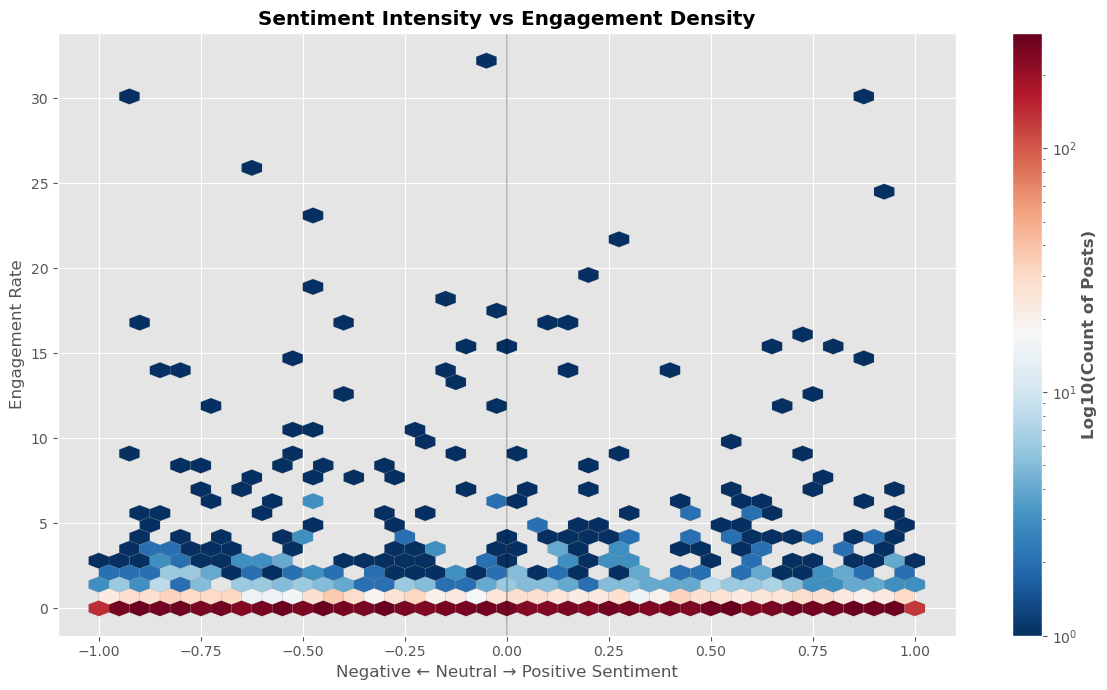

In [134]:
# 2. Sentiment vs Engagement Density

plt.figure(figsize=(12,7))
hb = plt.hexbin(df['sentiment_score'],df['engagement_rate'],gridsize=40,cmap='RdBu_r',
                bins='log',mincnt=1,edgecolors='grey',linewidths=0.1)
cb = plt.colorbar(hb)
cb.set_label('Log10(Count of Posts)',fontweight='bold')
plt.title('Sentiment Intensity vs Engagement Density',fontweight='bold')
plt.xlabel('Negative ← Neutral → Positive Sentiment')
plt.ylabel('Engagement Rate')
plt.axvline(0,color='black',alpha=0.2)
plt.tight_layout()
plt.show()

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\1398712497.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_eng = (df.groupby('day_of_week')['engagement_rate'].mean().reindex(day_order)*100)


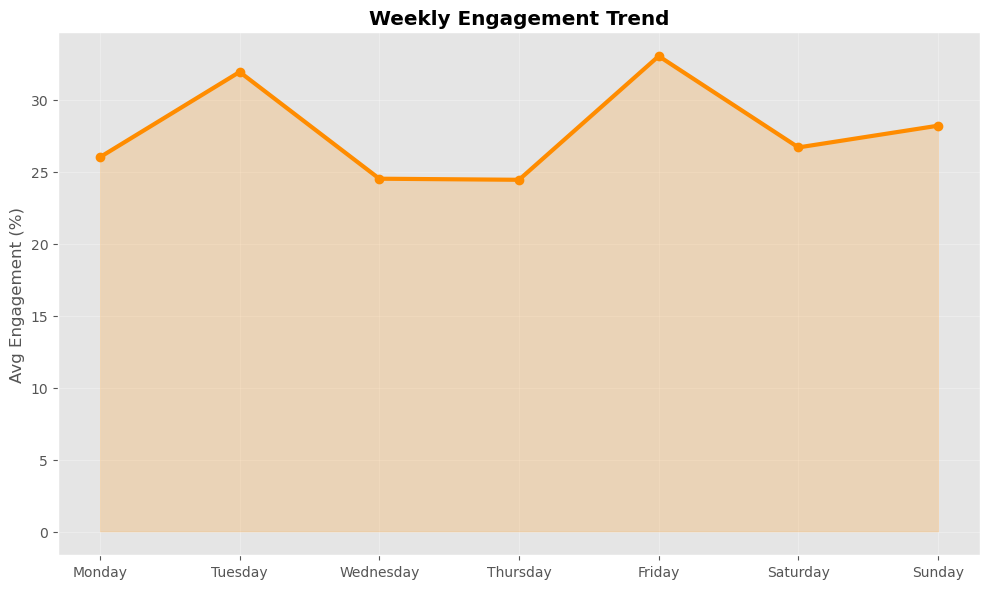

In [135]:
# 3. Weekly Engagement Trend

plt.figure(figsize=(10,6))
day_eng = (df.groupby('day_of_week')['engagement_rate'].mean().reindex(day_order)*100)
plt.plot(day_order,day_eng,marker='o',color='#FF8C00',linewidth=3)
plt.fill_between(day_order,day_eng,color='#FF8C00',alpha=0.2)
plt.title('Weekly Engagement Trend',fontweight='bold')
plt.ylabel('Avg Engagement (%)')
plt.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()


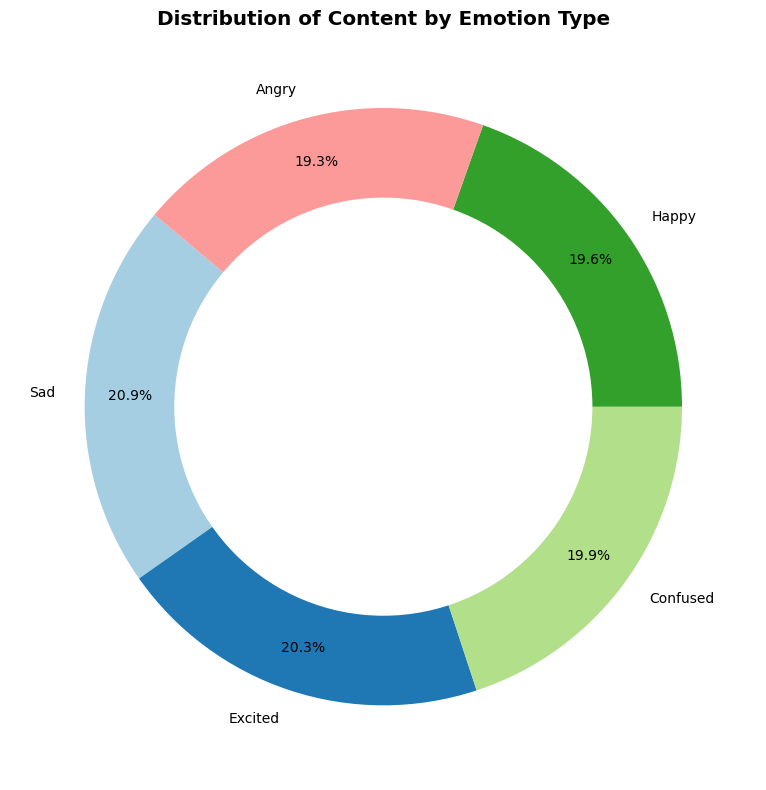

In [136]:
# 4. Emotion Distribution

plt.figure(figsize=(8,8))

emotion_counts = df['emotion_type'].value_counts()
plt.pie(emotion_counts,labels=emotion_counts.index,autopct='%1.1f%%',startangle=140,colors=plt.cm.
        Paired.colors,pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Distribution of Content by Emotion Type',fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\3494678715.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_data = (df.groupby('campaign_phase')['engagement_rate'].mean().sort_values(ascending=False)*100)


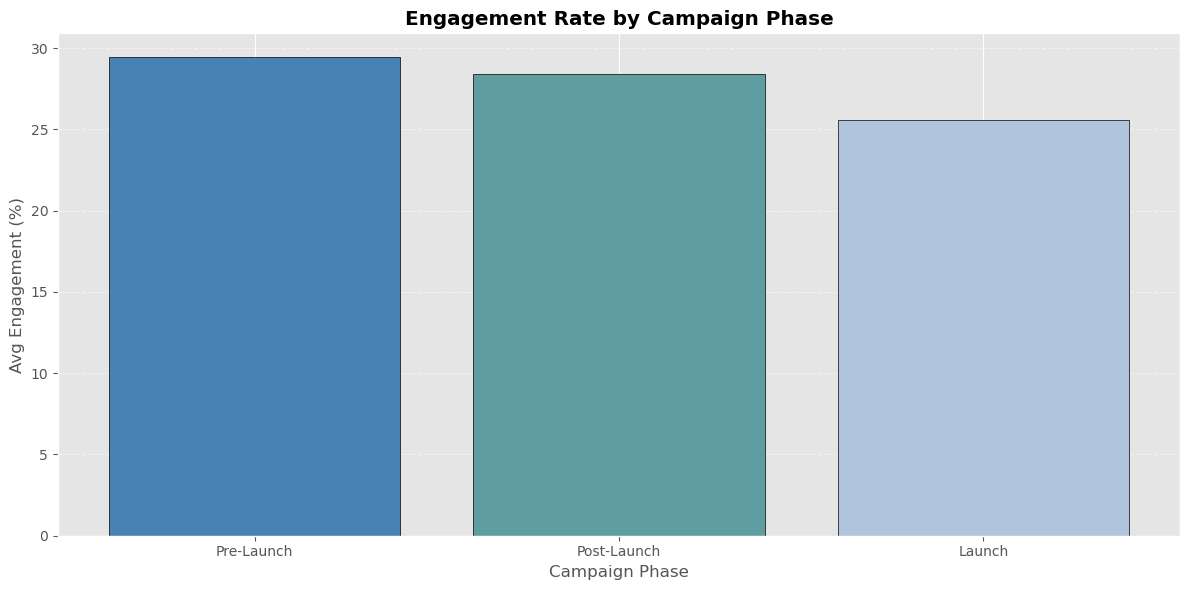

In [137]:
# 5. Campaign Phase Engagement

plt.figure(figsize=(12,6))

campaign_data = (df.groupby('campaign_phase')['engagement_rate'].mean().sort_values(ascending=False)*100)
plt.bar(campaign_data.index,campaign_data.values,color=['#4682B4','#5F9EA0','#B0C4DE'],edgecolor='black')
plt.title('Engagement Rate by Campaign Phase',fontweight='bold')
plt.ylabel('Avg Engagement (%)')
plt.xlabel('Campaign Phase')
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

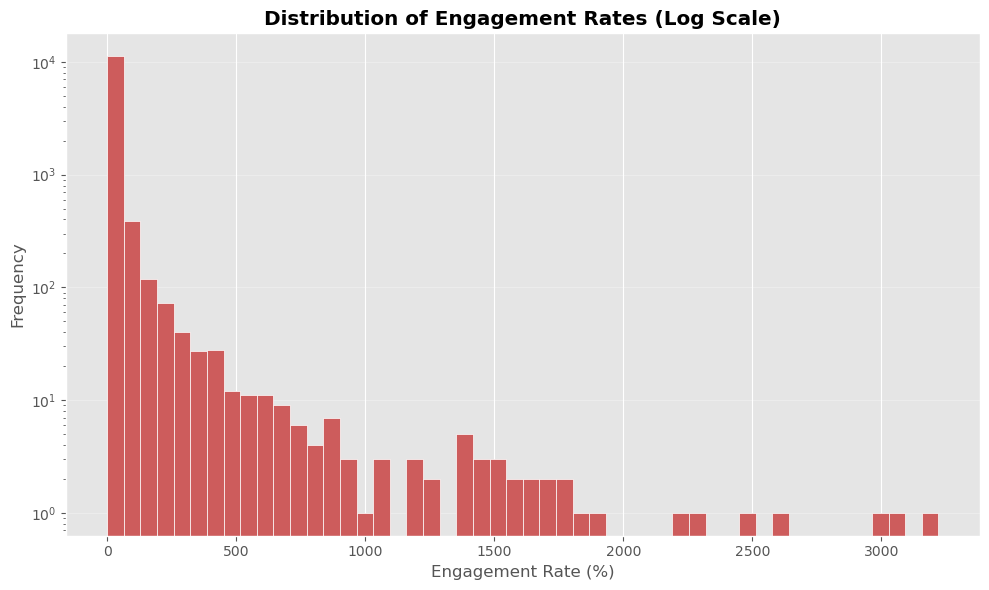

In [138]:
# 6. Engagement Rate Distribution

plt.figure(figsize=(10,6))
plt.hist(df['engagement_rate']*100,bins=50,color='#CD5C5C',edgecolor='white')
plt.yscale('log')
plt.title('Distribution of Engagement Rates (Log Scale)',fontweight='bold')
plt.xlabel('Engagement Rate (%)')
plt.ylabel('Frequency')
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

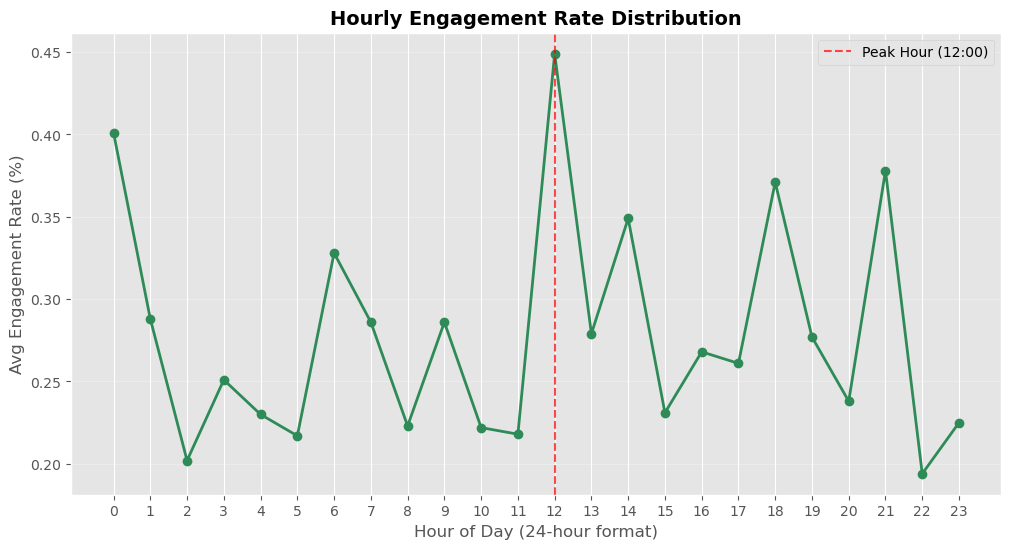

In [144]:
# 7. Horly Engagement Rate Distribution 
plt.figure(figsize=(12, 6))
plt.plot(hourly_engagement.index, hourly_engagement.values, 
         marker='o', linestyle='-', color='#2E8B57', linewidth=2)

plt.axvline(peak_hour, color='red', linestyle='--', alpha=0.7, label=f'Peak Hour ({peak_hour}:00)')
plt.title('Hourly Engagement Rate Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Avg Engagement Rate (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.show()

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\4046487937.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_perf = (df.groupby('brand_name')['engagement_rate'].mean().sort_values(ascending=False))


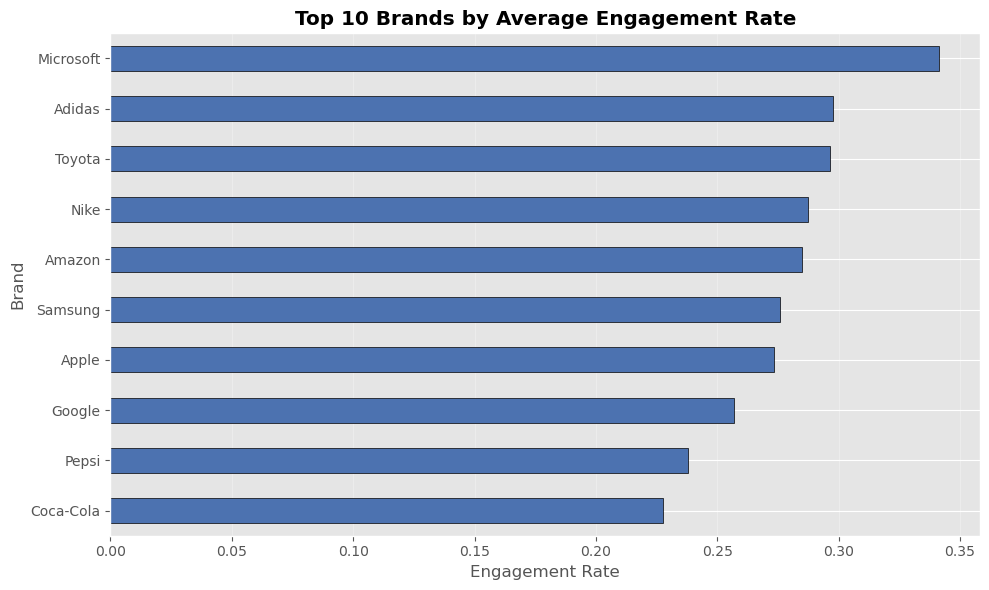

In [142]:
# 8. Brand Performance Chart

brand_perf = (df.groupby('brand_name')['engagement_rate'].mean().sort_values(ascending=False))
plt.figure(figsize=(10,6))
brand_perf.head(10).sort_values().plot(kind='barh',color='#4C72B0',edgecolor='black')

plt.title("Top 10 Brands by Average Engagement Rate", fontweight='bold')
plt.xlabel("Engagement Rate")
plt.ylabel("Brand")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\3106242166.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_perf = (df.groupby('product_name')['engagement_rate'].mean().sort_values(ascending=False))


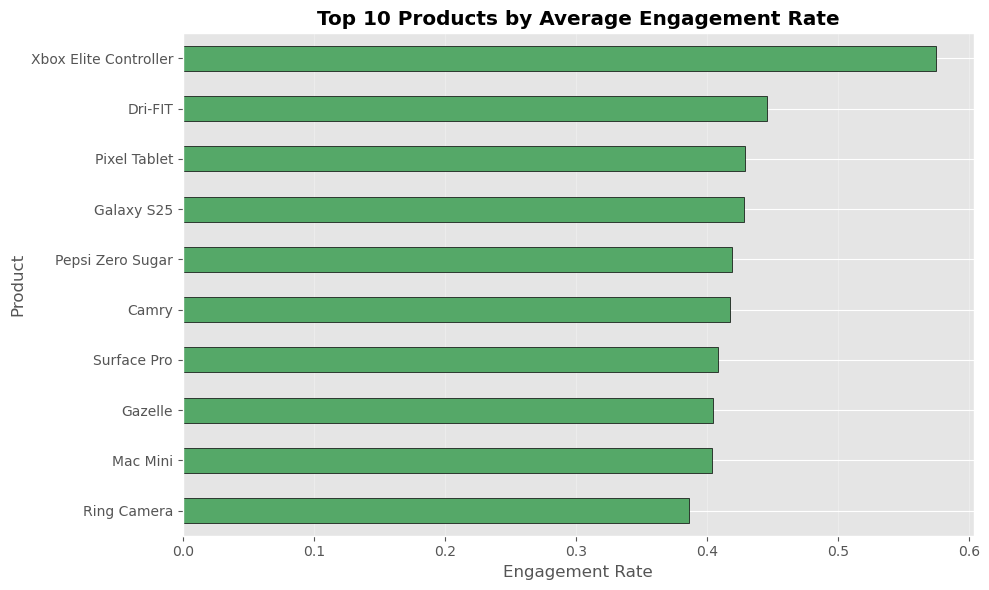

In [141]:
# 9. Product Performance Chart
product_perf = (df.groupby('product_name')['engagement_rate'].mean().sort_values(ascending=False))
plt.figure(figsize=(10,6))
product_perf.head(10).sort_values().plot(kind='barh',color='#55A868',edgecolor='black')

plt.title("Top 10 Products by Average Engagement Rate", fontweight='bold')
plt.xlabel("Engagement Rate")
plt.ylabel("Product")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\996594589.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_perf = (df.groupby('campaign_name')['engagement_rate'].mean().sort_values(ascending=False))


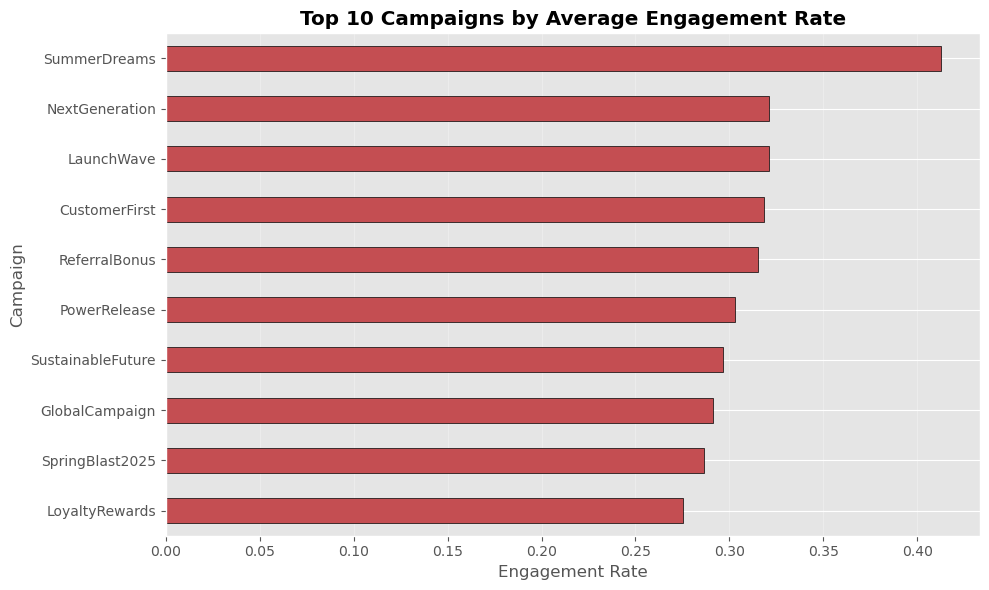

In [140]:
# 10. Campaign Performance Chart

campaign_perf = (df.groupby('campaign_name')['engagement_rate'].mean().sort_values(ascending=False))

plt.figure(figsize=(10,6))
campaign_perf.head(10).sort_values().plot(kind='barh',color='#C44E52',edgecolor='black')

plt.title("Top 10 Campaigns by Average Engagement Rate", fontweight='bold')
plt.xlabel("Engagement Rate")
plt.ylabel("Campaign")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 11. Location Engagement Heatmap
# Heatmap showing engagement by platform and location

location_heatmap = pd.pivot_table(df,values='engagement_rate',index='location',columns='platform',aggfunc='mean').fillna(0)
plt.figure(figsize=(12,8))
plt.imshow(location_heatmap, cmap='YlOrRd', aspect='auto')
plt.colorbar(label="Average Engagement Rate")
plt.xticks(range(len(location_heatmap.columns)),location_heatmap.columns,rotation=45)

plt.yticks(range(len(location_heatmap.index)),location_heatmap.index)

plt.title("Engagement Rate Heatmap (Location vs Platform)", fontweight='bold')
plt.xlabel("Platform")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

C:\Users\Parag Patil\AppData\Local\Temp\ipykernel_25216\2735895059.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  location_heatmap = pd.pivot_table(df,values='engagement_rate',index='location',columns='platform',aggfunc='mean').fillna(0)


In [151]:
# -------------------------------------------------
# PHASE 5 SUMMARY: VISUAL ANALYTICS
# - Platform comparison shows Instagram and Facebook generating
#   the strongest engagement performance.
# - Weekly trend visualization confirms higher engagement on
#   specific days such as Friday and Tuesday.
# - Emotional content distribution appears relatively balanced
#   across different emotion categories.
# - Campaign phase visualization indicates stronger engagement
#   during Pre-Launch campaigns.
# - Engagement rate distribution follows a long-tail pattern,
#   where most posts receive moderate engagement while a small
#   number achieve exceptionally high interaction levels.
# -------------------------------------------------